# WO8a — Environment–culture correspondence: descriptive probes (Societies)

Descriptive notebook (no engine / API / UI). Builds the shared **society → basin → signature**
substrate (Part A), draws nested-bet **PCoA** ordinations coloured by **EA042 subsistence** and
**WO7 modality** (Part B), the **seasonality-representation fork** (Part C), and the
**modality-standalone bet** (Part D).

**Accept gate:** in at least one bet's PCoA, does EA042 subsistence *visibly separate*? EA042 is
near-tautologically environmental (foragers / pastoralists / intensive farmers occupy different
environments almost by definition) — the positive-control calibration. No statistical test here;
that is WO8b/8c.

WO: `docs/cdop/pilot/wo8a_culture-probes.md`.

In [1]:
# Cell 1
%matplotlib inline
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage

from scripts.shared.db_utils import db_connect
import scripts.shared.db_utils as db_utils
from app.db import climate_classes as cc      # reuse WO7 classifiers: classify_modality / classify_phase
from app.db import seasonality as se          # reuse pre_concentration (_circ_conc_angle) + curve normaliser

ROOT = Path(db_utils.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'cdop'
OUT.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}\n"
      f"OUT : {OUT}\n"
      f"reused: cc.classify_modality/classify_phase | se._circ_conc_angle (pre_concentration) | "
      f"se._row_normalise (raw-curve correlation)")

ROOT: /Users/karlg/Documents/repos/_edops
OUT : /Users/karlg/Documents/repos/_edops/output/cdop
reused: cc.classify_modality/classify_phase | se._circ_conc_angle (pre_concentration) | se._row_normalise (raw-curve correlation)


In [2]:
# Cell 2
# Verify the shared substrate before consuming it (Part A provisos):
#   (1) society_basin is L08-keyed and the EA join count matches WO4 (~1,133 of 1,291);
#   (2) every WO-named predictor resolves to a real basin08 column.
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")
conn = db_connect()

join_counts = pd.read_sql("""
    SELECT COUNT(*)                       AS ea_total,
           COUNT(sb.basin_id)             AS joined_l08,
           COUNT(*) - COUNT(sb.basin_id)  AS unjoined
    FROM dplace.societies s
    LEFT JOIN dplace.society_basin sb
           ON sb.soc_id = s.id AND sb.basin_level = 8
    WHERE s.contribution_id = 'dplace-dataset-ea'
""", conn)

levels = pd.read_sql("""
    SELECT basin_level, COUNT(*) AS n
    FROM dplace.society_basin GROUP BY basin_level ORDER BY basin_level
""", conn)

pred_cols = ['ari_ix_sav','pre_mm_syr','run_mm_syr','slp_dg_sav','ele_mt_sav',
             'soc_th_sav','cly_pc_sav','slt_pc_sav','snd_pc_sav']
present = pd.read_sql(f"""
    SELECT column_name FROM information_schema.columns
    WHERE table_schema='public' AND table_name='basin08'
      AND column_name IN ({','.join("'" + c + "'" for c in pred_cols)})
""", conn)
conn.close()
missing = sorted(set(pred_cols) - set(present['column_name']))

print("\n".join([
    "EA society -> L08 basin join:", join_counts.to_string(index=False),
    "", "society_basin levels present:", levels.to_string(index=False),
    "", f"basin08 predictor columns missing: {missing if missing else 'none'}",
]))

EA society -> L08 basin join:
 ea_total  joined_l08  unjoined
     1291        1133       158

society_basin levels present:
 basin_level    n
           8 1133

basin08 predictor columns missing: none


In [4]:
# Cell 3 -- Part A: assemble + persist the shared substrate (society_id + hybas_id + s-signature).
# Temperature: raw basin08 tmp_dc_syr is stored x10 (CLAUDE.md); we instead take the annual thermal
# level from the persist-view monthly mean (already deg C), sidestepping the x10 trap. Other monthly-
# derived quantities (tmp_seas_amp, pre_concentration, modality, phase, raw curve) also come from the
# persist view. Static scalar predictors come straight from basin08. -9999 -> NaN before any use.
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")
conn = db_connect()

# 3a. Society -> L08 basin -> static scalar predictors + EA042 subsistence + EA034 religion.
soc = pd.read_sql("""
    SELECT s.id AS soc_id, s.name, s.longitude AS lon, s.latitude AS lat,
           sb.basin_id AS hybas_id,
           b.ari_ix_sav, b.pre_mm_syr, b.run_mm_syr, b.slp_dg_sav,
           b.ele_mt_sav, b.soc_th_sav, b.cly_pc_sav, b.slt_pc_sav, b.snd_pc_sav,
           c.name   AS ea042_subsistence,
           rel.name AS ea034_religion
    FROM dplace.societies s
    JOIN dplace.society_basin sb ON sb.soc_id = s.id AND sb.basin_level = 8
    JOIN basin08 b ON b.hybas_id = sb.basin_id
    LEFT JOIN dplace.data  d   ON d.soc_id  = s.id AND d.var_id  = 'EA042'
    LEFT JOIN dplace.codes c   ON c.id = d.code_id
         AND c.name NOT IN ('Missing data','','Missing for at least 1 activity','Two or more sources')
    LEFT JOIN dplace.data  rd  ON rd.soc_id = s.id AND rd.var_id = 'EA034'
    LEFT JOIN dplace.codes rel ON rel.id = rd.code_id AND rel.name != 'Missing data'
    WHERE s.contribution_id = 'dplace-dataset-ea'
""", conn)
soc['hybas_id'] = soc['hybas_id'].astype('int64')

# Guard the EA042/EA034 code joins against fan-out (one code per society expected).
dup = int(soc.duplicated('soc_id').sum())
soc = soc.drop_duplicates('soc_id').reset_index(drop=True)

# 3b. Monthly curves for the joined basins (persist view: tmp already deg C, not x10).
hy = tuple(int(x) for x in sorted(soc['hybas_id'].unique()))
arr = pd.read_sql(f"""
    SELECT hybas_id, pre_mm_monthly, tmp_dc_monthly
    FROM public.v_basin08_persist_rev2
    WHERE hybas_id IN {hy}
""", conn)
conn.close()
arr['hybas_id'] = arr['hybas_id'].astype('int64')

PRE = np.array(arr['pre_mm_monthly'].tolist(), dtype=float)
TMP = np.array(arr['tmp_dc_monthly'].tolist(), dtype=float)   # already deg C
pre_total = PRE.sum(axis=1)
tmp_amp   = TMP.max(axis=1) - TMP.min(axis=1)

with np.errstate(invalid='ignore', divide='ignore'):   # flat-curve basins -> NaN pt_corr (benign; thermal gate handles them)
    phase, pt = cc.classify_phase(PRE, TMP, tmp_amp)
der = pd.DataFrame({
    'hybas_id':           arr['hybas_id'].to_numpy(),
    'temperature_annual': TMP.mean(axis=1),
    'tmp_seas_amp':       tmp_amp,
    'pre_concentration':  se._circ_conc_angle(PRE)[0],
    'modality':           cc.classify_modality(PRE, pre_total),
    'phase':              phase,
    'pt_corr':            pt,
    'pre_mm_monthly':     [r.tolist() for r in PRE],   # kept for Part C rep 2 (raw-curve correlation)
})

sub = soc.merge(der, on='hybas_id', how='left')

# 3c. Mask BasinATLAS NoData (-9999 -> NaN) on the static scalar predictors (zero is a value).
scalar_cols = ['ari_ix_sav','pre_mm_syr','run_mm_syr','slp_dg_sav',
               'ele_mt_sav','soc_th_sav','cly_pc_sav','slt_pc_sav','snd_pc_sav']
sub[scalar_cols] = sub[scalar_cols].replace(-9999, np.nan)

# 3d. Persist for WO8b/8c reuse.
out_path = OUT / 'wo8a_substrate.parquet'
sub.to_parquet(out_path, index=False)

# 3e. Single-print summary.
lines = [
    f"substrate rows: {len(sub)}  |  unique basins: {sub['hybas_id'].nunique()}  "
    f"|  EA042 fan-out duplicates dropped: {dup}",
    f"saved -> {out_path}",
    "",
    "EA042 subsistence (non-missing):",
    sub['ea042_subsistence'].value_counts(dropna=False).to_string(),
    "",
    "WO7 modality class:",
    sub['modality'].value_counts(dropna=False).to_string(),
    "",
    "predictor NaN counts (post -9999 mask):",
    sub[scalar_cols].isna().sum().to_string(),
    "",
    "NB container caveat rides along (disclosed, not fixed): basin mean != site; at L08 ~13.4% of",
    "societies still show a >2 C implied gap (WO4 Part 0B). A correct read of the source, not a fix target.",
]
print("\n".join(lines))

substrate rows: 1133  |  unique basins: 971  |  EA042 fan-out duplicates dropped: 0
saved -> /Users/karlg/Documents/repos/_edops/output/cdop/wo8a_substrate.parquet

EA042 subsistence (non-missing):
ea042_subsistence
Extensive agriculture        401
Intensive agriculture        265
Gathering                     99
Fishing                       85
Hunting                       77
Pastoralism                   76
Agriculture, type unknown     75
None                          55

WO7 modality class:
modality
1-season        924
2-season         98
aseasonal        61
arid             34
undetermined     16

predictor NaN counts (post -9999 mask):
ari_ix_sav     0
pre_mm_syr     0
run_mm_syr     0
slp_dg_sav     2
ele_mt_sav     0
soc_th_sav    10
cly_pc_sav    10
slt_pc_sav    10
snd_pc_sav    10

NB container caveat rides along (disclosed, not fixed): basin mean != site; at L08 ~13.4% of
societies still show a >2 C implied gap (WO4 Part 0B). A correct read of the source, not a fix target.

In [5]:
# Cell 4 -- helpers: distances (Euclidean / correlation / class-disagreement), hand-rolled classical
# PCoA (Torgerson), a bet-matrix builder, and a panel plotter. Reload the substrate so Part B-D are
# decoupled from Cell 3 state.
sub = pd.read_parquet(OUT / 'wo8a_substrate.parquet')
PRE_ALL = np.array(sub['pre_mm_monthly'].tolist(), dtype=float)   # (N,12) raw curves, row-aligned to sub


def euclid(X):
    """Pairwise Euclidean distance for a z-scored (n,p) matrix; no scipy dependency."""
    G = X @ X.T
    d2 = np.diag(G)[:, None] + np.diag(G)[None, :] - 2 * G
    return np.sqrt(np.clip(d2, 0, None))


def corr_distance(rows):
    """sqrt(2(1-r)) chord distance on mean-centred / unit-norm curves (WO6b). Euclidean-embeddable."""
    Xn = se._row_normalise(rows)
    C = np.clip(Xn @ Xn.T, -1, 1)
    return np.sqrt(np.clip(2 * (1 - C), 0, None))


def class_distance(labels):
    """Gower on a single nominal variable: 0 if same class, 1 if different."""
    a = np.asarray(labels, dtype=object)
    return (a[:, None] != a[None, :]).astype(float)


def pcoa(D, k=3):
    """Classical PCoA (Torgerson): double-centre -0.5 J D^2 J, eigendecompose. Returns (coords, explained)."""
    D = np.asarray(D, float)
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J
    B = (B + B.T) / 2
    w, V = np.linalg.eigh(B)
    order = np.argsort(w)[::-1]
    w, V = w[order], V[:, order]
    wpos = np.clip(w, 0, None)
    coords = V[:, :k] * np.sqrt(wpos[:k])
    explained = wpos / wpos.sum() if wpos.sum() > 0 else np.zeros_like(wpos)
    return coords, explained


def bet_matrix(cols, transforms=None):
    """(Xz, kept_sub, corr_df) for a continuous bet: complete-case rows, optional per-col transform, z-scored."""
    d = sub.dropna(subset=cols).copy()
    X = d[cols].to_numpy(float)
    if transforms:
        for i, c in enumerate(cols):
            if transforms.get(c):
                X[:, i] = transforms[c](X[:, i])
    Xz = (X - X.mean(0)) / X.std(0)
    corr_df = pd.DataFrame(np.corrcoef(Xz, rowvar=False), index=cols, columns=cols)
    return Xz, d.reset_index(drop=True), corr_df


# EA042 palette: hue family encodes the forager->farmer axis (greens=agriculture, blues=foraging,
# orange=pastoralism, grey=none), so subsistence separation is readable at a glance.
EA042_COLORS = {
    'Intensive agriculture':     '#145A32',
    'Extensive agriculture':     '#2E8B57',
    'Agriculture, type unknown': '#7DCEA0',
    'Gathering':                 '#5DADE2',
    'Fishing':                   '#2874A6',
    'Hunting':                   '#1B4F72',
    'Pastoralism':               '#E67E22',
    'None':                      '#909497',
}
EA042_ORDER = list(EA042_COLORS)


def _panel(ax, coords, labels, palette, order, title, jitter_frac=0.0, seed=0):
    """Scatter PCo1 vs PCo2 coloured by a categorical. jitter_frac spreads degenerate (class/1D) layouts."""
    xy = coords[:, :2].astype(float).copy()
    if jitter_frac:
        span = np.ptp(xy, axis=0); span[span == 0] = 1.0
        xy = xy + np.random.default_rng(seed).normal(0, jitter_frac, xy.shape) * span
    lab = np.asarray(labels, dtype=object)
    for cat in order:
        m = (lab == cat)
        if m.any():
            ax.scatter(xy[m, 0], xy[m, 1], s=16, alpha=0.6, color=palette[cat],
                       edgecolors='none', label=str(cat))
    ax.set_title(title, color='black', fontsize=10)
    ax.set_xlabel('PCo1', color='black'); ax.set_ylabel('PCo2', color='black')
    ax.tick_params(colors='black')


print(f"helpers ready | substrate {sub.shape} | PRE_ALL {PRE_ALL.shape} | "
      f"EA042 palette {len(EA042_ORDER)} classes | modality palette from cc.MOD_COLORS")

helpers ready | substrate (1133, 23) | PRE_ALL (1133, 12) | EA042 palette 8 classes | modality palette from cc.MOD_COLORS


In [6]:
# Cell 5 -- Part B: within-bet correlation matrices FIRST (the composite-distance hazard made visible,
# not buried). Any |r| >= 0.70 pair is flagged as a Mahalanobis-or-drop candidate for WO8b. Nested bets:
# Water c Climate envelope c Landscape. Aridity is log1p-transformed (catalog position_method).
water_cols   = ['ari_ix_sav', 'pre_mm_syr', 'run_mm_syr']
climate_cols = water_cols + ['temperature_annual', 'tmp_seas_amp']
land_cols    = climate_cols + ['ele_mt_sav', 'slp_dg_sav']
LOG = {'ari_ix_sav': np.log1p}
BETS = {'Water': water_cols, 'Climate envelope': climate_cols, 'Landscape': land_cols}

report = []
for name, cols in BETS.items():
    _, kept, corr = bet_matrix(cols, LOG)
    hi = [(cols[i], cols[j], round(corr.iat[i, j], 2))
          for i in range(len(cols)) for j in range(i + 1, len(cols)) if abs(corr.iat[i, j]) >= 0.70]
    report += [f"=== {name}  (n={len(kept)} complete-case) ===",
               corr.round(2).to_string(),
               f"|r| >= 0.70 pairs (Mahalanobis / drop candidates for 8b): {hi if hi else 'none'}", ""]
print("\n".join(report))

=== Water  (n=1133 complete-case) ===
            ari_ix_sav  pre_mm_syr  run_mm_syr
ari_ix_sav        1.00        0.76        0.66
pre_mm_syr        0.76        1.00        0.83
run_mm_syr        0.66        0.83        1.00
|r| >= 0.70 pairs (Mahalanobis / drop candidates for 8b): [('ari_ix_sav', 'pre_mm_syr', np.float64(0.76)), ('pre_mm_syr', 'run_mm_syr', np.float64(0.83))]

=== Climate envelope  (n=1133 complete-case) ===
                    ari_ix_sav  pre_mm_syr  run_mm_syr  temperature_annual  tmp_seas_amp
ari_ix_sav                1.00        0.76        0.66               -0.11         -0.23
pre_mm_syr                0.76        1.00        0.83                0.35         -0.56
run_mm_syr                0.66        0.83        1.00                0.09         -0.28
temperature_annual       -0.11        0.35        0.09                1.00         -0.83
tmp_seas_amp             -0.23       -0.56       -0.28               -0.83          1.00
|r| >= 0.70 pairs (Mahalanobis / dr

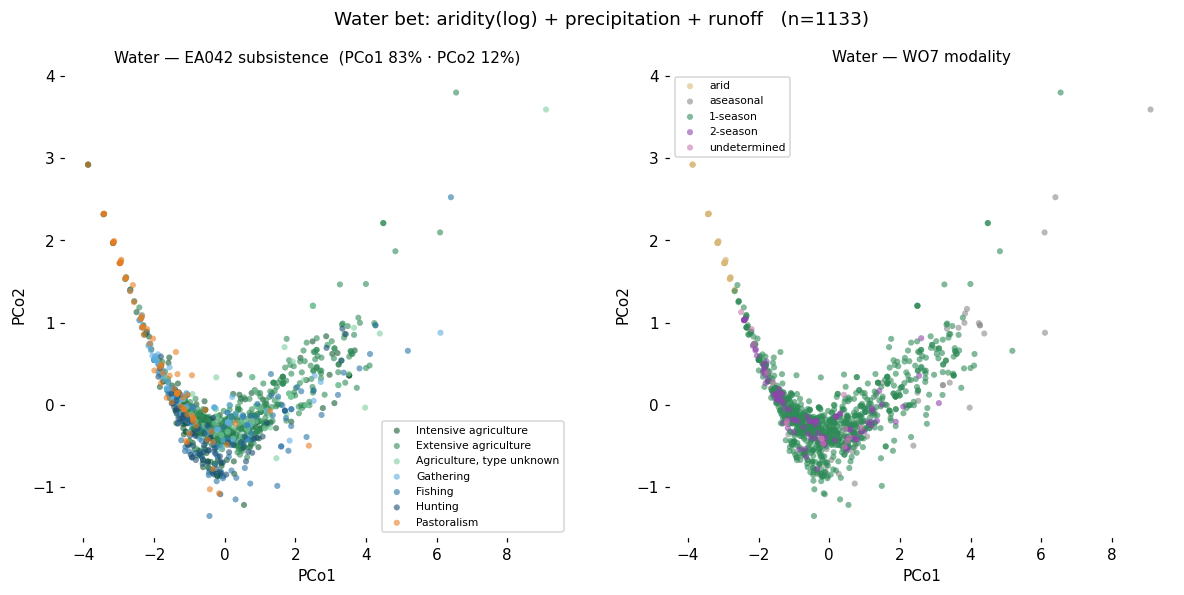

In [8]:
# Cell 6 -- Water bet PCoA (z-scored Euclidean). Same ordination coloured two ways:
# left = EA042 subsistence (the accept-gate control), right = WO7 modality (does the picture track rain regime?).
Xz, kept, _ = bet_matrix(water_cols, LOG)
coords, expl = pcoa(euclid(Xz))
print("drawing Water bet PCoA ...")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
_panel(axes[0], coords, kept['ea042_subsistence'], EA042_COLORS, EA042_ORDER,
       f"Water — EA042 subsistence  (PCo1 {expl[0]*100:.0f}% · PCo2 {expl[1]*100:.0f}%)")
_panel(axes[1], coords, kept['modality'], cc.MOD_COLORS, cc.MOD_ORDER, "Water — WO7 modality")
axes[0].legend(fontsize=7, loc='best', frameon=True, labelcolor='black')
axes[1].legend(fontsize=7, loc='best', frameon=True, labelcolor='black')
fig.suptitle(f"Water bet: aridity(log) + precipitation + runoff   (n={len(kept)})", color='black')
outp = OUT / 'wo8a_bet_water.png'
fig.savefig(outp, dpi=110, facecolor='white', bbox_inches='tight'); plt.close(fig)
display(IPImage(str(outp)))

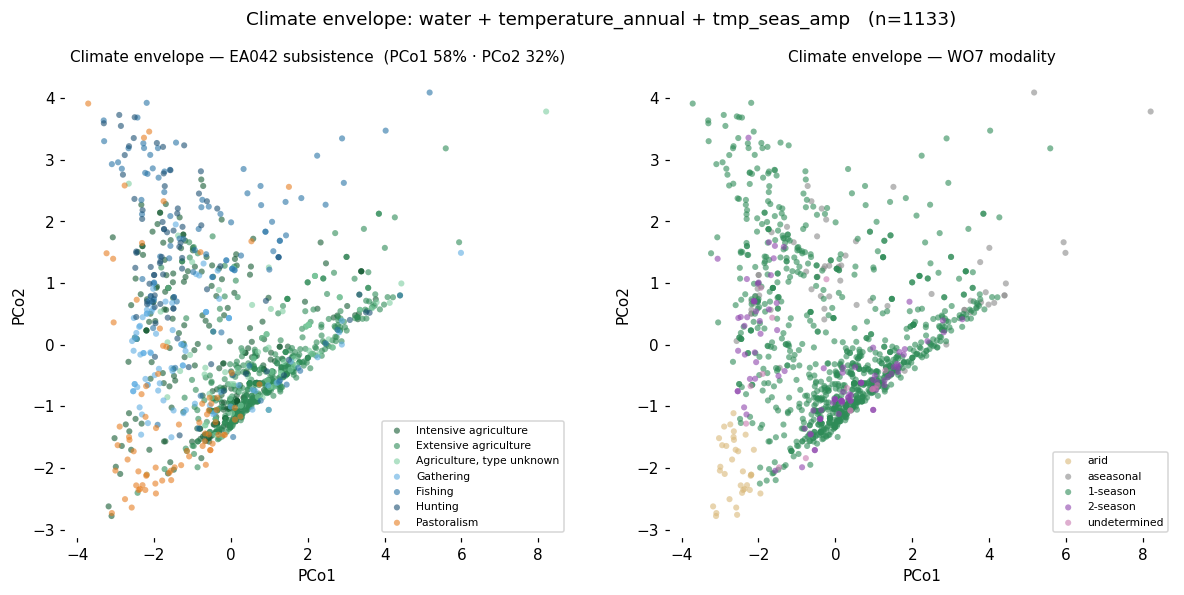

In [9]:
# Cell 7 -- Climate envelope bet PCoA (Water + annual temperature + seasonal amplitude). The standard
# bioclimatic-envelope bet: expected to be the natural host for the strongest subsistence separation.
Xz, kept, _ = bet_matrix(climate_cols, LOG)
coords, expl = pcoa(euclid(Xz))
print("drawing Climate-envelope bet PCoA ...")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
_panel(axes[0], coords, kept['ea042_subsistence'], EA042_COLORS, EA042_ORDER,
       f"Climate envelope — EA042 subsistence  (PCo1 {expl[0]*100:.0f}% · PCo2 {expl[1]*100:.0f}%)")
_panel(axes[1], coords, kept['modality'], cc.MOD_COLORS, cc.MOD_ORDER, "Climate envelope — WO7 modality")
axes[0].legend(fontsize=7, loc='best', frameon=True, labelcolor='black')
axes[1].legend(fontsize=7, loc='best', frameon=True, labelcolor='black')
fig.suptitle(f"Climate envelope: water + temperature_annual + tmp_seas_amp   (n={len(kept)})", color='black')
outp = OUT / 'wo8a_bet_climate.png'
fig.savefig(outp, dpi=110, facecolor='white', bbox_inches='tight'); plt.close(fig)
display(IPImage(str(outp)))

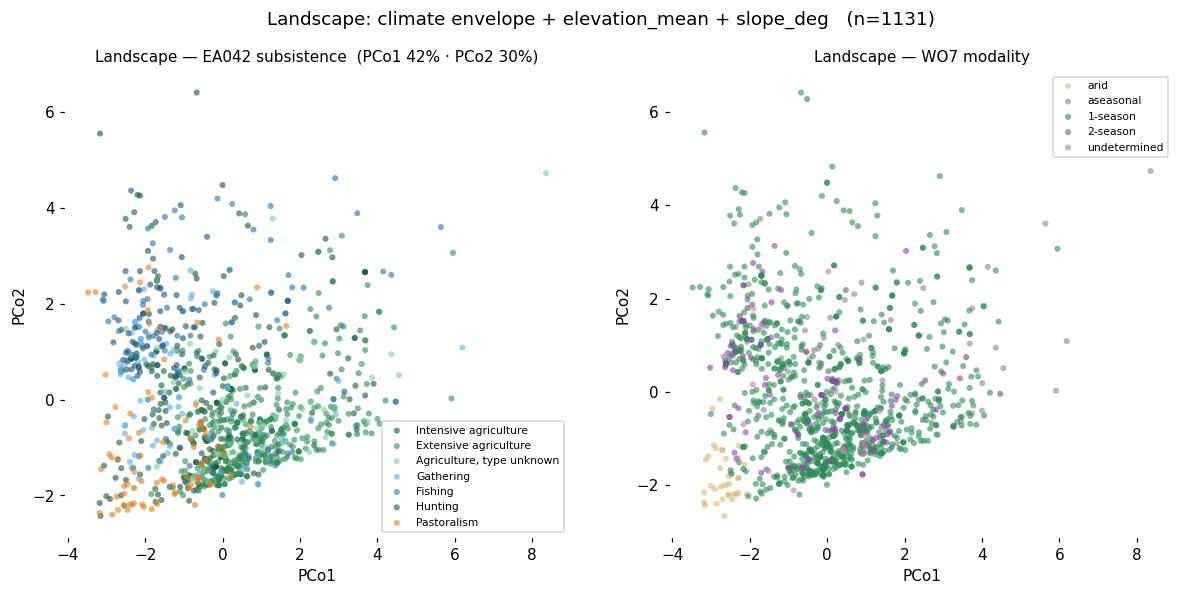

In [10]:
# Cell 8 -- Landscape bet PCoA (Climate envelope + elevation_mean + slope). The bet where terrain is
# expected to begin dominating the ordination -- and whether elevation *separates* or merely *smears*
# the subsistence groups is itself the test. (ele_mt_sav / slp_dg_sav are catalog-`planned`, read direct.)
Xz, kept, _ = bet_matrix(land_cols, LOG)
coords, expl = pcoa(euclid(Xz))
print("drawing Landscape bet PCoA ...")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
_panel(axes[0], coords, kept['ea042_subsistence'], EA042_COLORS, EA042_ORDER,
       f"Landscape — EA042 subsistence  (PCo1 {expl[0]*100:.0f}% · PCo2 {expl[1]*100:.0f}%)")
_panel(axes[1], coords, kept['modality'], cc.MOD_COLORS, cc.MOD_ORDER, "Landscape — WO7 modality")
axes[0].legend(fontsize=7, loc='best', frameon=True, labelcolor='black')
axes[1].legend(fontsize=7, loc='best', frameon=True, labelcolor='black')
fig.suptitle(f"Landscape: climate envelope + elevation_mean + slope_deg   (n={len(kept)})", color='black')
outp = OUT / 'wo8a_bet_landscape.png'
fig.savefig(outp, dpi=110, facecolor='white', bbox_inches='tight'); plt.close(fig)
display(IPImage(str(outp)))

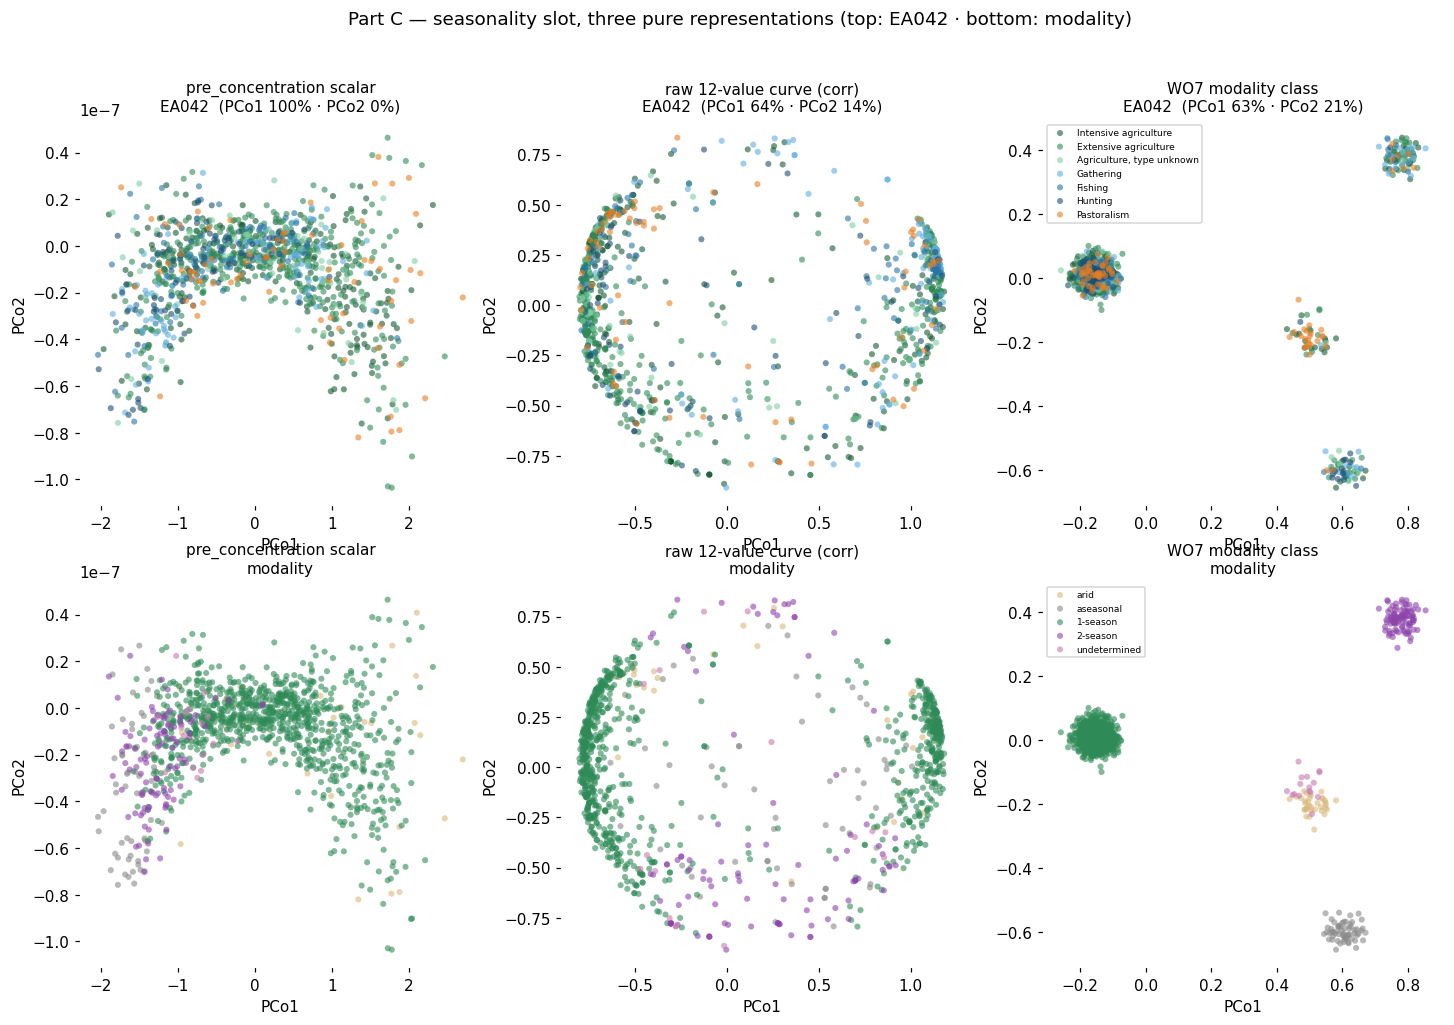

In [12]:
# Cell 9 -- Part C: the seasonality-representation fork. Three PURE representations of the seasonality
# slot (no combination -- combining a categorical with continuous axes is Gower, deferred), each its own
# distance, drawn side by side. Top row coloured by EA042 (does subsistence separate?), bottom by WO7
# modality. rep1 is included precisely so its known two-peaks-cancel failure is visible.
#
# Complete-case PER representation: a few hyper-arid basins have zero/flat precip, so pre_concentration
# and the raw-curve norm are undefined (NaN) -- and classical PCoA propagates a single NaN across the
# whole double-centred matrix (empty panel, "PCo 0%"). Those basins are legitimately undefined for a
# precip-SHAPE representation; drop them per rep (modality keeps them as 'arid'). n reported in the draw line.
d = sub.reset_index(drop=True)

conc = d['pre_concentration'].to_numpy(float)
m1 = np.isfinite(conc)                                    # rep1: drop undefined-concentration basins
conc_z = ((conc[m1] - conc[m1].mean()) / conc[m1].std())[:, None]

Xn = se._row_normalise(PRE_ALL)
m2 = np.isfinite(Xn).all(axis=1)                          # rep2: drop flat/zero curves (row-norm 0)

REPS = [
    ('pre_concentration scalar',  euclid(conc_z),                            m1,                    0.03),
    ('raw 12-value curve (corr)', corr_distance(PRE_ALL[m2]),                m2,                    0.0),
    ('WO7 modality class',        class_distance(d['modality'].to_numpy()),  np.ones(len(d), bool), 0.03),
]
print(f"drawing Part C seasonality-representation fork ... "
      f"(rep1 dropped {int((~m1).sum())} undefined-conc, rep2 dropped {int((~m2).sum())} flat-curve)")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('white')
for ax in axes.ravel():
    ax.set_facecolor('white')
for j, (title, D, mask, jit) in enumerate(REPS):
    coords, expl = pcoa(D)
    dd = d[mask]
    _panel(axes[0, j], coords, dd['ea042_subsistence'], EA042_COLORS, EA042_ORDER,
           f"{title}\nEA042  (PCo1 {expl[0]*100:.0f}% · PCo2 {expl[1]*100:.0f}%)", jitter_frac=jit)
    _panel(axes[1, j], coords, dd['modality'], cc.MOD_COLORS, cc.MOD_ORDER,
           f"{title}\nmodality", jitter_frac=jit)
axes[0, 2].legend(fontsize=6, loc='best', labelcolor='black')
axes[1, 2].legend(fontsize=6, loc='best', labelcolor='black')
fig.suptitle('Part C — seasonality slot, three pure representations (top: EA042 · bottom: modality)',
             color='black', fontsize=12)
outp = OUT / 'wo8a_partC_fork.png'
fig.savefig(outp, dpi=110, facecolor='white', bbox_inches='tight'); plt.close(fig)
display(IPImage(str(outp)))

In [15]:
# Cell 10 -- Part D (text): how EA042 subsistence distributes across the discrete WO7 classes. This is
# the coarse categorical corroborator -- a second method landing (or not) on the same fact as the
# continuous bets. Row-% modality reads down each subsistence type; the cell table is transposed
# (16 climate cells as rows, 7 subsistence types as columns) so the wide phase breakdown is legible.
d = sub.copy()
d['cell'] = [cc.cell_key(m, p) for m, p in zip(d['modality'], d['phase'])]
ct_mod  = pd.crosstab(d['ea042_subsistence'], d['modality'])
ct_cell = pd.crosstab(d['ea042_subsistence'], d['cell'])
ct_mod_pct = (ct_mod.div(ct_mod.sum(axis=1), axis=0) * 100).round(0).astype(int)
print("\n".join([
    "EA042 x WO7 modality (row %  -- reads across each subsistence type):", ct_mod_pct.to_string(), "",
    "EA042 x WO7 modality (counts):", ct_mod.to_string(), "",
    "(modality x phase) cell x EA042 (counts, transposed -- cells down, subsistence across):",
    ct_cell.T.to_string(),
]))

EA042 x WO7 modality (row %  -- reads across each subsistence type):
modality                   1-season  2-season  arid  aseasonal  undetermined
ea042_subsistence                                                           
Agriculture, type unknown        84         5     1          9             0
Extensive agriculture            87         7     0          4             2
Fishing                          88         6     0          6             0
Gathering                        69        21     1          9             0
Hunting                          81         3     0         16             1
Intensive agriculture            81        10     4          3             2
Pastoralism                      59         9    25          3             4

EA042 x WO7 modality (counts):
modality                   1-season  2-season  arid  aseasonal  undetermined
ea042_subsistence                                                           
Agriculture, type unknown        63         4     1 

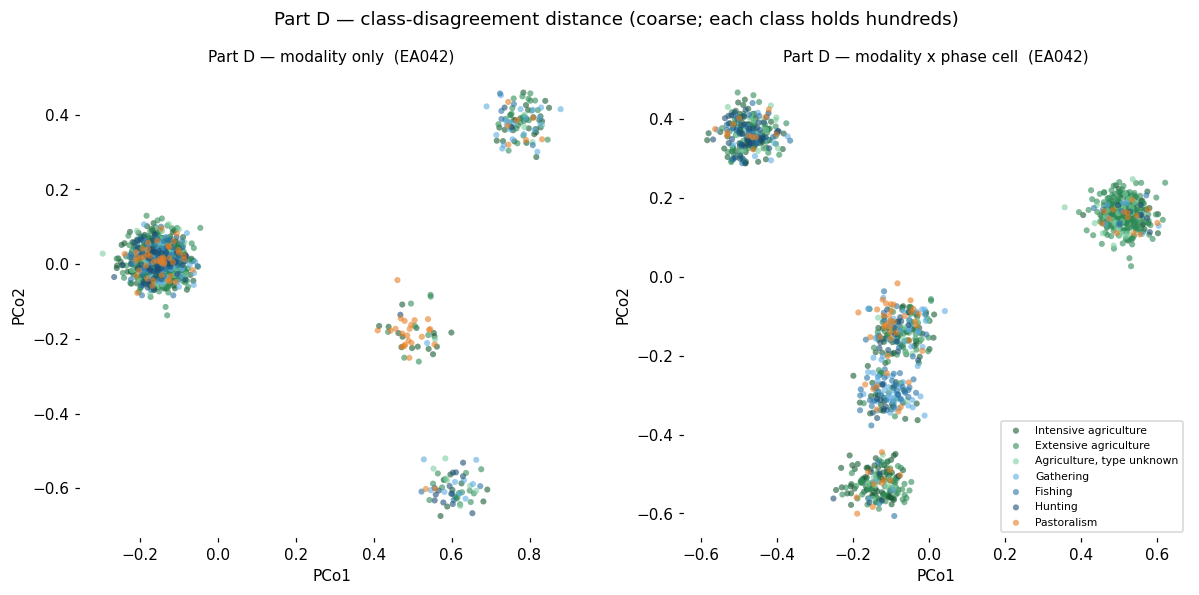

In [14]:
# Cell 11 -- Part D (figure): PCoA on PURE class-disagreement distance. Coarse by construction -- a class
# cell holds hundreds of societies, so points collapse to one location per class (jittered to show density).
# Left = modality only; right = modality x phase cell. Report as coarser, not a competitor at a different setting.
d = sub.copy()
d['cell'] = [cc.cell_key(m, p) for m, p in zip(d['modality'], d['phase'])]
print("drawing Part D class-disagreement PCoA ...")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
for ax, (labels, ttl) in zip(axes, [(d['modality'].to_numpy(), 'modality only'),
                                     (d['cell'].to_numpy(), 'modality x phase cell')]):
    coords, expl = pcoa(class_distance(labels))
    _panel(ax, coords, d['ea042_subsistence'], EA042_COLORS, EA042_ORDER,
           f"Part D — {ttl}  (EA042)", jitter_frac=0.04)
axes[1].legend(fontsize=7, loc='best', frameon=True, labelcolor='black')
fig.suptitle('Part D — class-disagreement distance (coarse; each class holds hundreds)', color='black')
outp = OUT / 'wo8a_partD_class.png'
fig.savefig(outp, dpi=110, facecolor='white', bbox_inches='tight'); plt.close(fig)
display(IPImage(str(outp)))

## Accept gate — RESULT: **PASSED**

EA042 subsistence **visibly separates**, most clearly in the Climate envelope bet. The positive
control fires → the instrument is calibrated and WO8b has a legitimate ruler for a contested trait.

**The bet ladder (Cells 6–8):**
- **Water** — one wetness axis (PCo1 83%); poles separate (pastoralism dry / agriculture wet), the
  middle jumbled. The floor.
- **Climate envelope — the winner.** Temperature opens a real second axis (PCo2 12% → 32%); the
  dry-left jam resolves into cold foragers (upper-left) vs warm-dry pastoralists (lower-left), with
  agriculture in the wet-mild quadrant. Three modes → three regions.
- **Landscape** — elevation + slope add a subsistence-*orthogonal* third axis (top-2 variance
  90% → 72%) that smears rather than separates. Over-reaches.

**The three decisions:**

1. **Bet into 8b → Climate envelope.** The sweet spot: captures the separating temperature axis
   without Landscape's terrain dilution.
2. **Seasonality representation → raw 12-value curve, but flagged non-load-bearing.** Part C (Cell 9):
   *none* of the three representations separates subsistence — rainfall timing/shape/modality is
   largely orthogonal to it (what matters is how much water + how warm, not when the rain falls). This
   refutes the WO's expectation that the modality class would separate cleanest; the picture wins. Of
   the three, the raw curve is faithful (phase ring + emergent modality, no cancellation bug); the
   `pre_concentration` scalar is actively misleading (2-season lands mid-axis — the Mombasa bug
   visible); the class is lossy. Carry the raw curve *only if* 8b wants a seasonality term.
3. **Keep modality-standalone (Part D) → yes, as the categorical corroborator**, read via the Cell 10
   **crosstab** (not the Cell 11 blob PCoA, which only shows classes hold everything). The crosstab
   independently lands: pastoralism → 25% arid (vs ≤4%), intensive-ag → 4% arid (= irrigation),
   fishing/gathering → cool-wet coastal-temperate (Pacific-NW pattern), extensive-ag → tropical
   no-thermal-cycle. A second, coarser method confirming the environment↔subsistence link.

**Headline — environment sets bounds, it does not determine.** One near-hard constraint (water for
rain-fed agriculture; intensive ag reaches arid only via irrigation), one soft gradient
(temperature/continentality), broad adaptability everywhere else (rainfall timing, elevation). EA042
is near-tautologically environmental and still only *partially* separates — so a contested trait
(EA034 high-gods, 8c) should be expected to couple *weakly*; the value there is an honest effect size
+ family-controlled null, not a big separation.

No statistical test here — PERMANOVA / PERMDISP with within-family restricted permutation is **WO8b**,
on the Climate envelope bet.